# Load Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

path = '/content/drive/MyDrive/DA/Colab/virtual-vehicle-sensor/Dataset/train.csv'
raw_df = pd.read_csv(path)
raw_df.head()

,Epm_nEng_100ms,VehV_v_100ms,ActMod_trqInr_100ms,RngMod_trqCrSmin_100ms,CoVeh_trqAcs_100ms,Clth_st_100ms,CoEng_st_100ms,Com_rTSC1VRVCURtdrTq_100ms,Com_rTSC1VRRDTrqReq_100ms,RoadSlope_100ms,Vehicle_Mass
0,902.5,67.72,1971.9360,-140.0,9.999747,0,3,0,0,1.5,38.0
1,1241.0,63.87,2604.0000,-196.0,9.999747,0,3,0,0,1.7,38.0
2,903.0,67.28,2208.0700,-140.0,9.999747,0,3,0,0,1.3,38.0
3,934.5,68.34,0.0000,-140.0,9.999747,0,3,0,0,-2.7,49.0
4,969.0,61.28,392.5794,-112.0,9.999747,0,3,0,0,2.3,49.0


The data contains 11 signals from the vehicle. The first 9 signals can be used as input for the prediction, the last 2 are the desired output.

# Exploratory Data Analysis (EDA)

## Missing Values
=> No missing values

In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8496 entries, 0 to 8495
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Epm_nEng_100ms              8496 non-null   float64
 1   VehV_v_100ms                8496 non-null   float64
 2   ActMod_trqInr_100ms         8496 non-null   float64
 3   RngMod_trqCrSmin_100ms      8496 non-null   float64
 4   CoVeh_trqAcs_100ms          8496 non-null   float64
 5   Clth_st_100ms               8496 non-null   int64  
 6   CoEng_st_100ms              8496 non-null   int64  
 7   Com_rTSC1VRVCURtdrTq_100ms  8496 non-null   int64  
 8   Com_rTSC1VRRDTrqReq_100ms   8496 non-null   int64  
 9   RoadSlope_100ms             8496 non-null   float64
 10  Vehicle_Mass                8496 non-null   float64
dtypes: float64(7), int64(4)
memory usage: 730.3 KB


In [4]:
raw_df.isnull().sum()

,0
Epm_nEng_100ms,0
VehV_v_100ms,0
ActMod_trqInr_100ms,0
RngMod_trqCrSmin_100ms,0
CoVeh_trqAcs_100ms,0
Clth_st_100ms,0
CoEng_st_100ms,0
Com_rTSC1VRVCURtdrTq_100ms,0
Com_rTSC1VRRDTrqReq_100ms,0
RoadSlope_100ms,0


No missing values.

## Correlation
=> Drop 5 useless features \
=> Combined_VehV_RngMod

In [5]:
raw_df.describe()

,Epm_nEng_100ms,VehV_v_100ms,ActMod_trqInr_100ms,RngMod_trqCrSmin_100ms,CoVeh_trqAcs_100ms,Clth_st_100ms,CoEng_st_100ms,Com_rTSC1VRVCURtdrTq_100ms,Com_rTSC1VRRDTrqReq_100ms,RoadSlope_100ms,Vehicle_Mass
count,8496.000000,8496.000000,8496.000000,8496.000000,8.496000e+03,8496.0,8496.0,8496.0,8496.0,8496.000000,8496.000000
mean,1104.671257,64.349988,1419.595527,-158.917143,9.999747e+00,0.0,3.0,0.0,0.0,0.877949,41.595457
std,157.267374,10.691505,989.412153,26.449961,3.481864e-13,0.0,0.0,0.0,0.0,2.201932,5.160024
min,481.500000,38.310000,0.000000,-308.000000,9.999747e+00,0.0,3.0,0.0,0.0,-4.800000,38.000000
25%,948.375000,57.092500,363.923300,-168.000000,9.999747e+00,0.0,3.0,0.0,0.0,-0.400000,38.000000
50%,1145.000000,67.375000,1627.500000,-168.000000,9.999747e+00,0.0,3.0,0.0,0.0,1.000000,38.000000
75%,1192.500000,71.580000,2348.739000,-140.000000,9.999747e+00,0.0,3.0,0.0,0.0,2.100000,49.000000
max,2119.500000,88.930000,2688.000000,-84.000000,9.999747e+00,0.0,3.0,0.0,0.0,5.000000,49.000000


In [6]:
# Extract unique values for each column
for col in raw_df.columns:
    unique_vals = raw_df[col].unique()
    unique_count = len(unique_vals)
    print(f"{col}: {unique_count} unique values")
    if unique_count < 10:  # Only print values if the list is manageable
        print(f"  Values: {unique_vals}")

Epm_nEng_100ms: 1269 unique values
VehV_v_100ms: 3205 unique values
ActMod_trqInr_100ms: 2303 unique values
RngMod_trqCrSmin_100ms: 233 unique values
CoVeh_trqAcs_100ms: 1 unique values
  Values: [9.999747]
Clth_st_100ms: 1 unique values
  Values: [0]
CoEng_st_100ms: 1 unique values
  Values: [3]
Com_rTSC1VRVCURtdrTq_100ms: 1 unique values
  Values: [0]
Com_rTSC1VRRDTrqReq_100ms: 1 unique values
  Values: [0]
RoadSlope_100ms: 160 unique values
Vehicle_Mass: 2 unique values
  Values: [38. 49.]


Drop 5 columns with only a single unique value as they provide no analytical value.

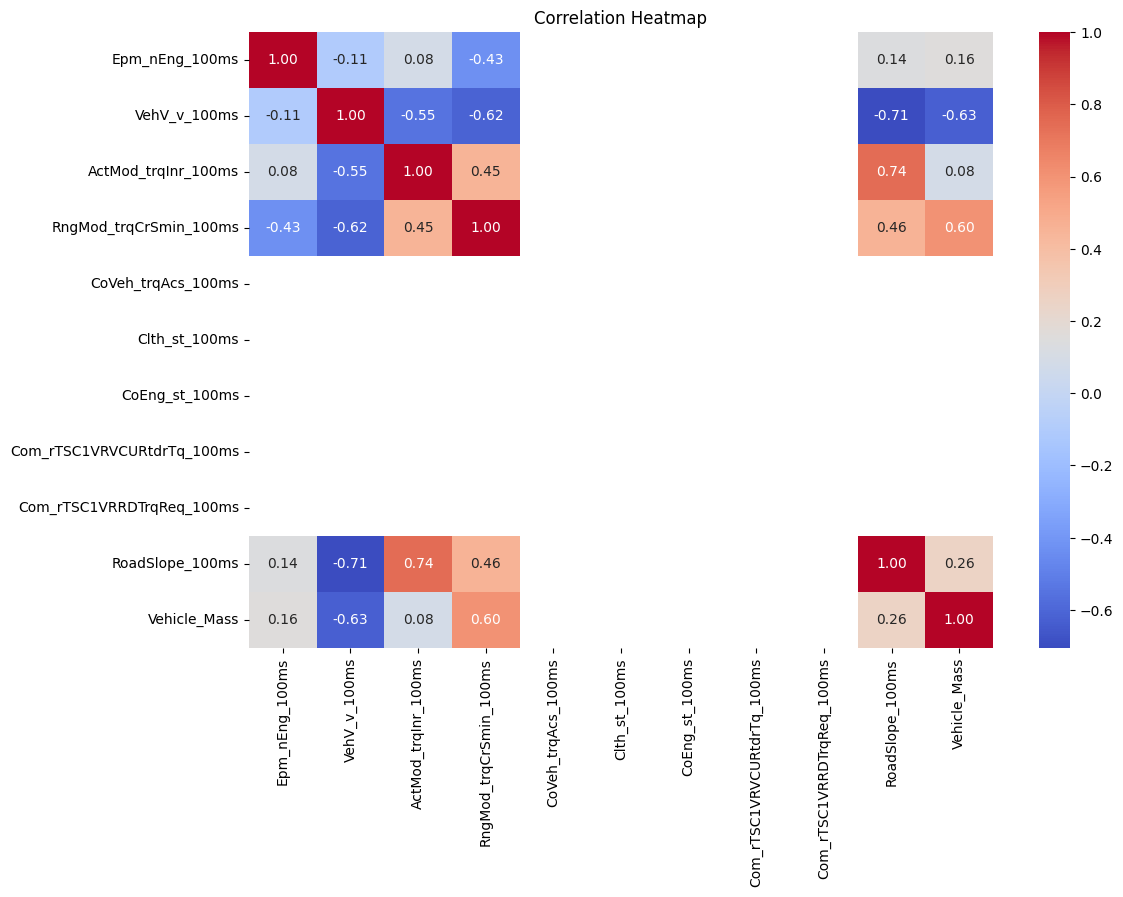

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = raw_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Combine VehV & RngMod as there is the strong negative correlation (-0.62) between the 2 features.

In [8]:
# Summary of Correlation
correlation_summary = correlation_matrix[['RoadSlope_100ms', 'Vehicle_Mass']].sort_values(by='RoadSlope_100ms', ascending=False)
correlation_summary

,RoadSlope_100ms,Vehicle_Mass
RoadSlope_100ms,1.000000,0.257673
ActMod_trqInr_100ms,0.743515,0.084114
RngMod_trqCrSmin_100ms,0.459027,0.604168
Vehicle_Mass,0.257673,1.000000
Epm_nEng_100ms,0.138132,0.156700
VehV_v_100ms,-0.705378,-0.630015
CoVeh_trqAcs_100ms,NaN,NaN
Clth_st_100ms,NaN,NaN
CoEng_st_100ms,NaN,NaN
Com_rTSC1VRVCURtdrTq_100ms,NaN,NaN


The correlation heatmap indicates NaN values for these 5 columns, likely due to constant values.

## Outlier Detection
=> Use Robust Scaler

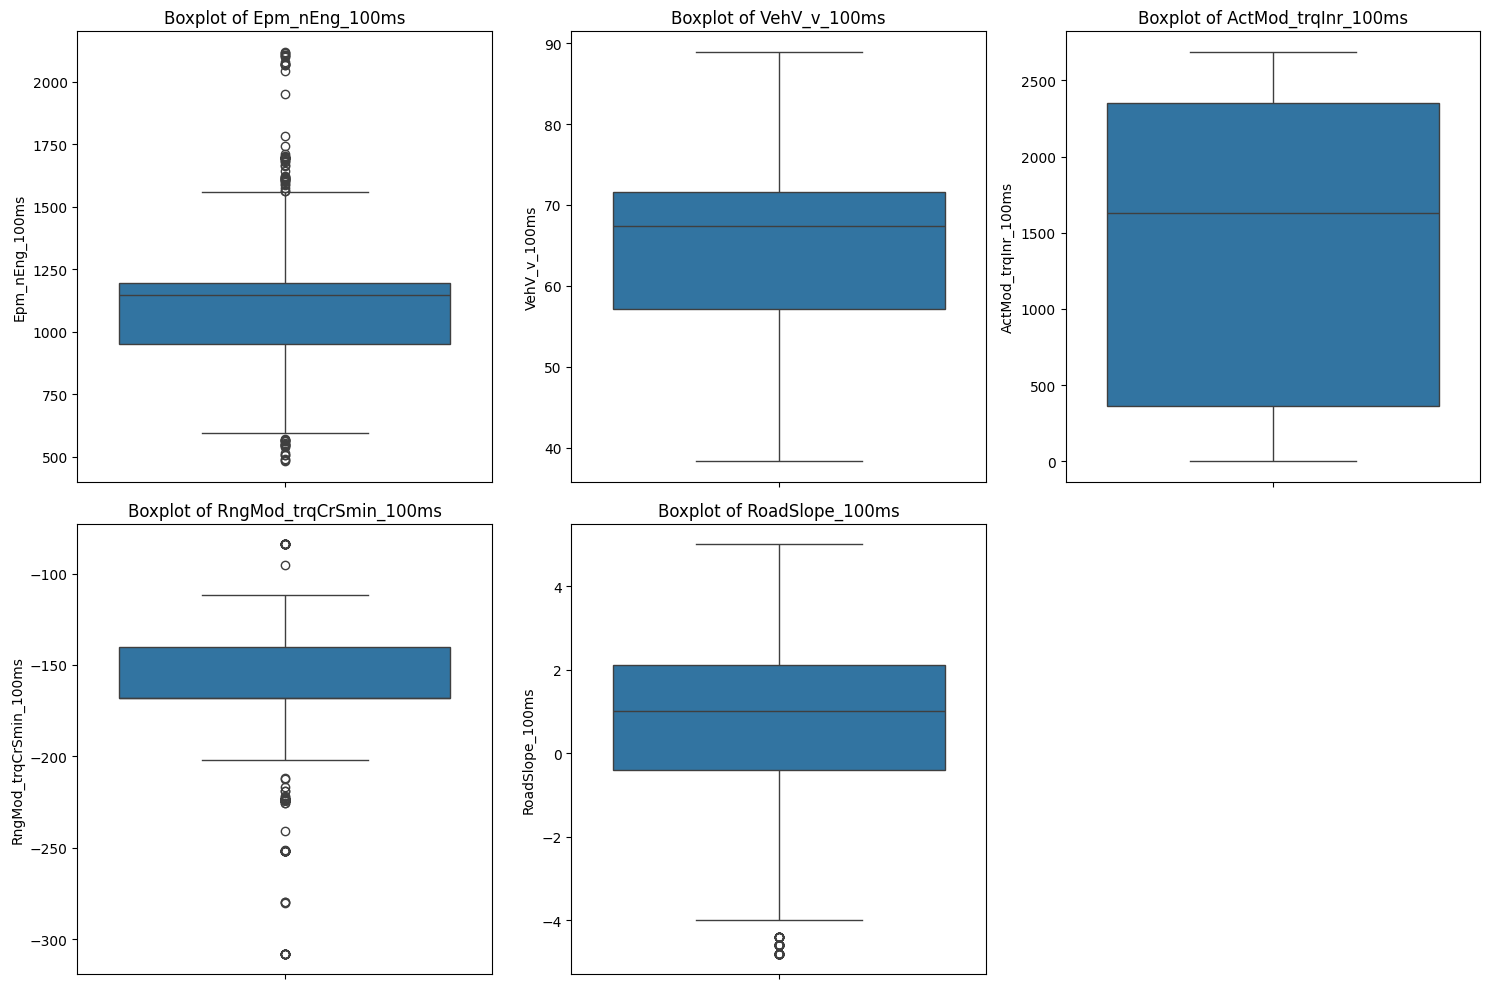

In [9]:
continuous_features = ['Epm_nEng_100ms', 'VehV_v_100ms', 'ActMod_trqInr_100ms', 'RngMod_trqCrSmin_100ms', 'RoadSlope_100ms']

plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=raw_df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [10]:
raw_df['RngMod_trqCrSmin_100ms'].describe()

,RngMod_trqCrSmin_100ms
count,8496.000000
mean,-158.917143
std,26.449961
min,-308.000000
25%,-168.000000
50%,-168.000000
75%,-140.000000
max,-84.000000


The median overlaps with the first quartile (Q1), indicating that a large portion of the data is concentrated at the same value, which makes the median line not visible in the boxplot of 'RngMod_trqCrSmin_100ms'.

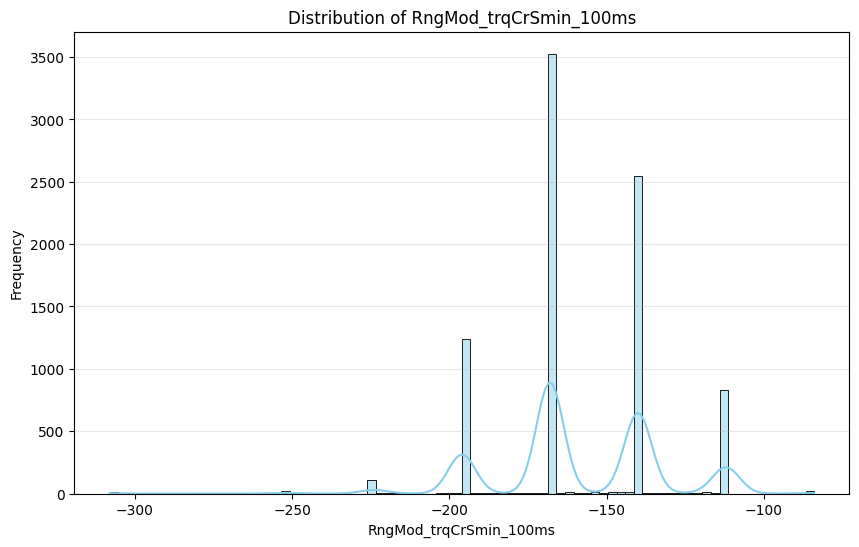

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(raw_df['RngMod_trqCrSmin_100ms'], kde=True, color='skyblue')
plt.title('Distribution of RngMod_trqCrSmin_100ms')
plt.xlabel('RngMod_trqCrSmin_100ms')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

Apply **RobustScaler** due to the presence of outliers and skewed data, as it is less sensitive to extreme values.

## Label Distribution
=> Use stratify=y

/tmp/ipykernel_2747/2148007972.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Vehicle_Mass', data=raw_df, ax=axes[1], palette='viridis')


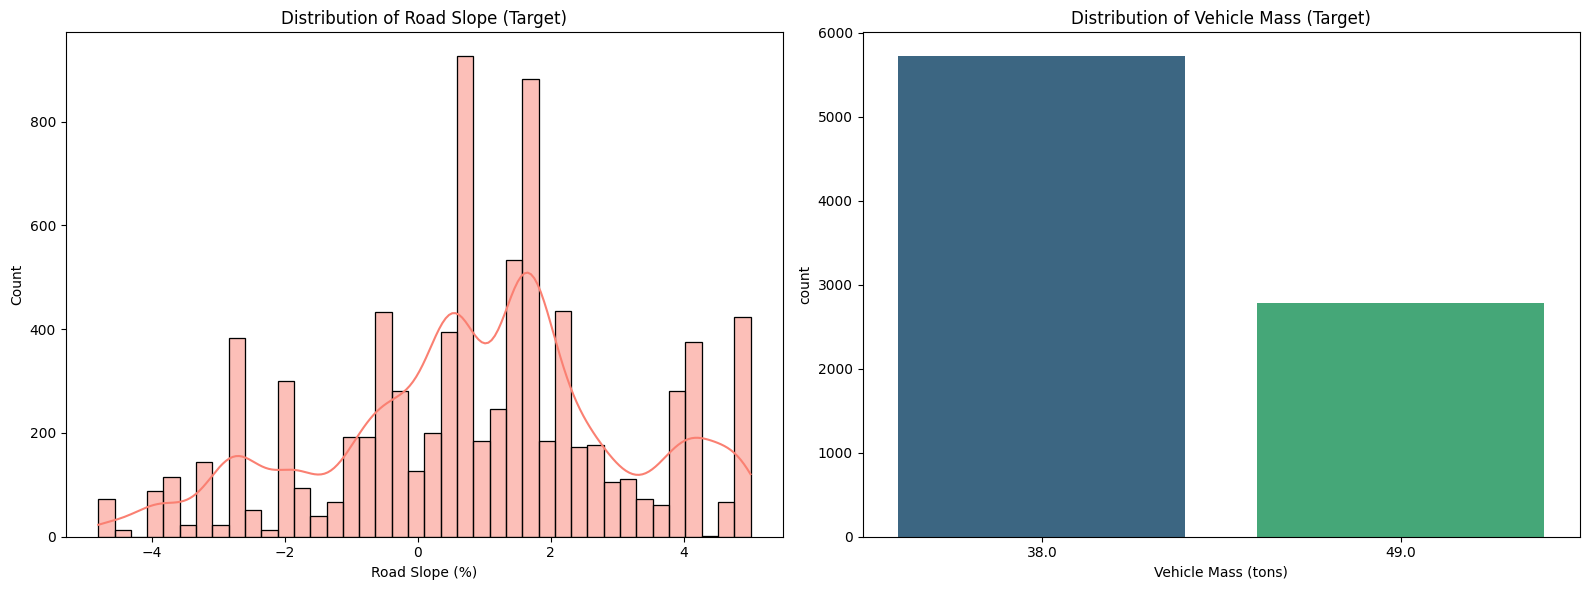

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of RoadSlope_100ms (Regression Target)
sns.histplot(raw_df['RoadSlope_100ms'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Road Slope (Target)')
axes[0].set_xlabel('Road Slope (%)')

# Distribution of Vehicle_Mass (Classification Target)
sns.countplot(x='Vehicle_Mass', data=raw_df, ax=axes[1], palette='viridis')
axes[1].set_title('Distribution of Vehicle Mass (Target)')
axes[1].set_xlabel('Vehicle Mass (tons)')

plt.tight_layout()
plt.show()

During data splitting, apply **stratification (stratify=y)** to preserve the original class distribution across the splits.

# Data Preparation

## Feature Removing

In [13]:
# Drop columns with only a single unique value
cols_to_drop = [
    'CoVeh_trqAcs_100ms',
    'Clth_st_100ms',
    'CoEng_st_100ms',
    'Com_rTSC1VRVCURtdrTq_100ms',
    'Com_rTSC1VRRDTrqReq_100ms'
]
dropped_df = raw_df.drop(columns=cols_to_drop)

# Verify the remaining columns
print(f"Dropped {len(cols_to_drop)} columns. Remaining columns:")
dropped_df.head()

Dropped 5 columns. Remaining columns:


,Epm_nEng_100ms,VehV_v_100ms,ActMod_trqInr_100ms,RngMod_trqCrSmin_100ms,RoadSlope_100ms,Vehicle_Mass
0,902.5,67.72,1971.9360,-140.0,1.5,38.0
1,1241.0,63.87,2604.0000,-196.0,1.7,38.0
2,903.0,67.28,2208.0700,-140.0,1.3,38.0
3,934.5,68.34,0.0000,-140.0,-2.7,49.0
4,969.0,61.28,392.5794,-112.0,2.3,49.0


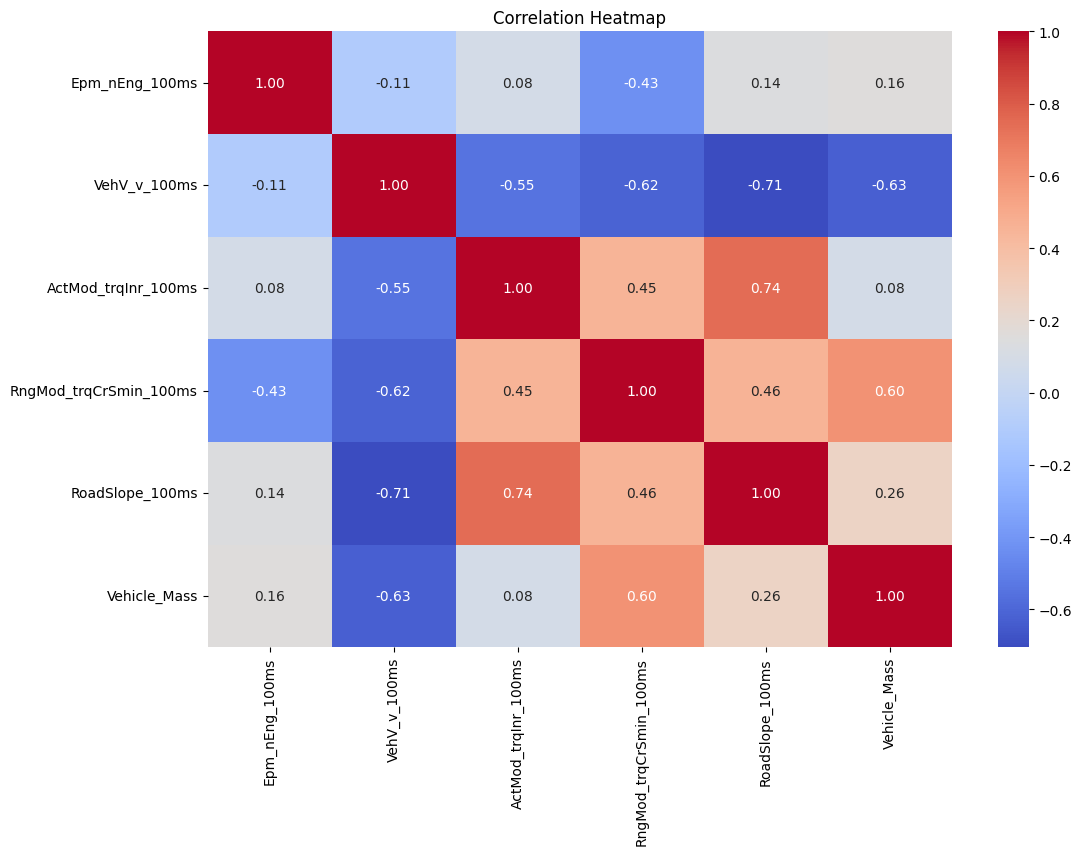

In [14]:
# New Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = dropped_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Combine Features

In [15]:
# Adding epsilon (1e-6) to prevent division by zero errors

epsilon = 1e-6

dropped_df['Combined_VehV_RngMod'] = dropped_df['VehV_v_100ms'] / (dropped_df['RngMod_trqCrSmin_100ms'] + epsilon)

print("New feature 'Combined_VehV_RngMod' added to the dataframe.")
dropped_df[['VehV_v_100ms', 'RngMod_trqCrSmin_100ms', 'Combined_VehV_RngMod']].head()

New feature 'Combined_VehV_RngMod' added to the dataframe.


,VehV_v_100ms,RngMod_trqCrSmin_100ms,Combined_VehV_RngMod
0,67.72,-140.0,-0.483714
1,63.87,-196.0,-0.325867
2,67.28,-140.0,-0.480571
3,68.34,-140.0,-0.488143
4,61.28,-112.0,-0.547143


## Data Splitting

In [16]:
from sklearn.model_selection import train_test_split

# Define features (X) and targets (y)
X = dropped_df.drop(columns=['RoadSlope_100ms', 'Vehicle_Mass'])
y_regression = dropped_df['RoadSlope_100ms']
y_classification = dropped_df['Vehicle_Mass']

# Split into Train (70%) and Temp (30%)
X_train, X_temp, y_reg_train, y_reg_temp, y_clf_train, y_clf_temp = train_test_split(
    X, y_regression, y_classification,
    test_size=0.30,
    random_state=42,
    stratify=y_classification
)

# Split Temp (30%) into Dev (15%) and Test (15%)
X_dev, X_test, y_reg_dev, y_reg_test, y_clf_dev, y_clf_test = train_test_split(
    X_temp, y_reg_temp, y_clf_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_clf_temp
)

print(f"Training set size: {len(X_train)} (70%)")
print(f"Dev set size:      {len(X_dev)} (15%)")
print(f"Test set size:     {len(X_test)} (15%)")

Training set size: 5947 (70%)
Dev set size:      1274 (15%)
Test set size:     1275 (15%)


## Encoding for Classification Label

In [17]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit on training labels and transform all sets
y_clf_train_encoded = le.fit_transform(y_clf_train)
y_clf_dev_encoded = le.transform(y_clf_dev)
y_clf_test_encoded = le.transform(y_clf_test)

# Display the mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Label Mapping: {mapping}")
print(f"Encoded training labels (first 5): {y_clf_train_encoded[:5]}")

Label Mapping: {np.float64(38.0): np.int64(0), np.float64(49.0): np.int64(1)}
Encoded training labels (first 5): [1 0 1 0 0]


## Scaling

In [18]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Initialize RobustScaler
scaler = RobustScaler()

# Fit on training data and transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_dev_scaled = pd.DataFrame(X_dev_scaled, columns=X_dev.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Modeling

## Scoring

In [19]:
import numpy as np

def reg_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    errors = np.abs(y_pred - y_true)
    points = np.zeros_like(errors, dtype=float)

    points[(errors >= 0.0) & (errors < 0.001)] = 1.0
    points[(errors >= 0.001) & (errors < 0.01)] = 0.5
    points[(errors >= 0.01) & (errors < 0.02)] = 0.25
    points[(errors >= 0.02) & (errors < 0.05)] = 0.0
    points[(errors >= 0.05) & (errors < 0.3)] = -0.25
    points[(errors >= 0.3)] = -0.5

    return np.mean(points)

In [20]:
from sklearn.metrics import recall_score
import numpy as np

def clf_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    r0 = recall_score(y_true, y_pred, pos_label=0)
    r1 = recall_score(y_true, y_pred, pos_label=1)

    return np.sqrt(r0 * r1)

In [21]:
def combined_score(y_reg_true, y_reg_pred,
                   y_clf_true, y_clf_pred,
                   verbose=True):
    """
    Evaluate both regression & classification + combined score
    """

    reg = reg_score(y_reg_true, y_reg_pred)
    clf = clf_score(y_clf_true, y_clf_pred)
    final = reg + clf

    if verbose:
        print(f"Regression score: {reg:.4f}")
        print(f"Classification score: {clf:.4f}")
        print(f"Final score: {final:.4f}")

    return {
        "reg_score": reg,
        "clf_score": clf,
        "combined_score": final
    }

## Classification

--- Evaluating Models for Vehicle Mass Classification ---

Logistic Regression: G-mean = 0.9865
Random Forest: G-mean = 0.9964
Gradient Boosting: G-mean = 0.9946
SVM: G-mean = 0.9970

--- Final Summary ---


,Model,G-mean
3,SVM,0.997012
1,Random Forest,0.996430
2,Gradient Boosting,0.994601
0,Logistic Regression,0.986467


/tmp/ipykernel_2747/2006249033.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='G-mean', y='Model', data=results_df, palette='coolwarm')


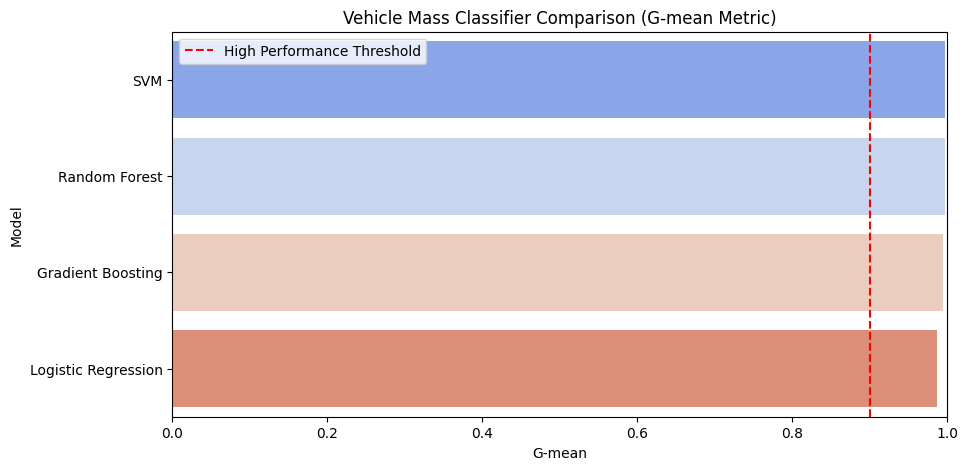

In [23]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42, class_weight='balanced')
}

results = []

print("--- Evaluating Models for Vehicle Mass Classification ---\n")

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_clf_train_encoded)

    # Predict
    y_pred = model.predict(X_dev_scaled)

    # Calculate G-mean
    g_mean = clf_score(y_clf_dev_encoded, y_pred)

    results.append({"Model": name, "G-mean": g_mean})
    print(f"{name}: G-mean = {g_mean:.4f}")

# Summary Table
results_df = pd.DataFrame(results).sort_values(by='G-mean', ascending=False)
print("\n--- Final Summary ---")
display(results_df)

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='G-mean', y='Model', data=results_df, palette='coolwarm')
plt.axvline(0.9, color='red', linestyle='--', label='High Performance Threshold')
plt.title('Vehicle Mass Classifier Comparison (G-mean Metric)')
plt.xlim(0, 1.0)
plt.legend()
plt.show()

## Regression

In [32]:
from sklearn.svm import SVR
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import pandas as pd

# Define the regressors including KNN with default parameters
reg_models = {
    "KNN (Default)": KNeighborsRegressor(),
    "SVR": SVR(),
    "Bagging Regressor": BaggingRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

reg_results = []

print("--- Evaluating Regression Models (Default Parameters) ---\n")

for name, model in reg_models.items():
    # Train
    model.fit(X_train_scaled, y_reg_train)

    # Predict
    y_pred_val = model.predict(X_dev_scaled)

    # Score
    score = reg_score(y_reg_dev, y_pred_val)

    reg_results.append({"Model": name, "Reg Score": score})
    print(f"{name}: reg_score = {score:.4f}")

# Summary Table
reg_comparison_df = pd.DataFrame(reg_results).sort_values(by='Reg Score', ascending=False)
print("\n--- Regression Model Comparison ---")
display(reg_comparison_df)

--- Evaluating Regression Models (Default Parameters) ---

KNN (Default): reg_score = 0.3361
SVR: reg_score = -0.3077
Bagging Regressor: reg_score = 0.2763
Gradient Boosting: reg_score = -0.3401
XGBoost: reg_score = -0.1849

--- Regression Model Comparison ---


,Model,Reg Score
0,KNN (Default),0.336146
2,Bagging Regressor,0.276295
4,XGBoost,-0.184851
1,SVR,-0.307692
3,Gradient Boosting,-0.340071


--- Tuning KNN Regressor for Road Slope (Expanded Search) ---



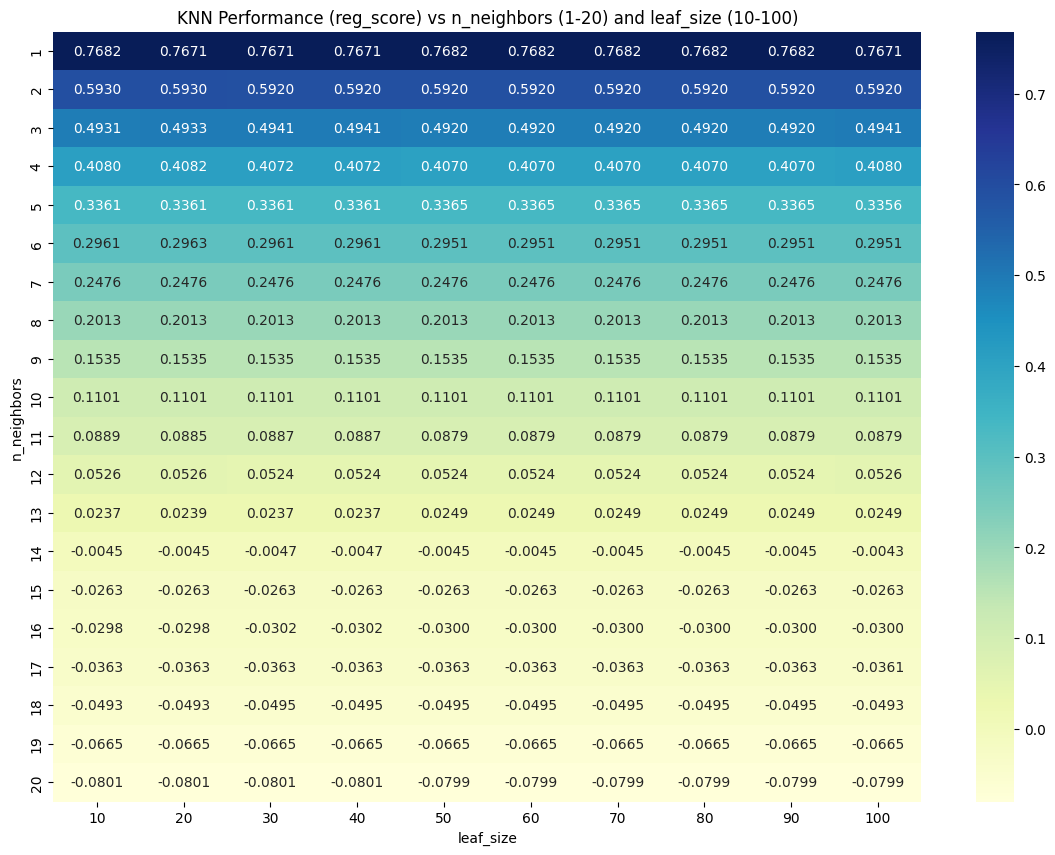


Best Performance:
n_neighbors: 1.0
leaf_size: 10.0
Best reg_score: 0.7682


In [33]:
from sklearn.neighbors import KNeighborsRegressor
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the updated parameter grid with expanded n_neighbors and leaf_size
n_neighbors_list = list(range(1, 21))
leaf_sizes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

results = []

print("--- Tuning KNN Regressor for Road Slope (Expanded Search) ---\n")

for n in n_neighbors_list:
    for leaf in leaf_sizes:
        # Initialize and train
        knn = KNeighborsRegressor(n_neighbors=n, leaf_size=leaf)
        knn.fit(X_train_scaled, y_reg_train)

        # Predict on dev set
        y_reg_pred = knn.predict(X_dev_scaled)

        # Calculate custom reg_score
        score = reg_score(y_reg_dev, y_reg_pred)

        results.append({
            'n_neighbors': n,
            'leaf_size': leaf,
            'reg_score': score
        })

# Convert to DataFrame for analysis
results_df = pd.DataFrame(results)

# Pivot for heatmap visualization
pivot_table = results_df.pivot(index='n_neighbors', columns='leaf_size', values='reg_score')

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("KNN Performance (reg_score) vs n_neighbors (1-20) and leaf_size (10-100)")
plt.show()

# Find and print the best parameters
best_result = results_df.loc[results_df['reg_score'].idxmax()]
print(f"\nBest Performance:")
print(f"n_neighbors: {best_result['n_neighbors']}")
print(f"leaf_size: {best_result['leaf_size']}")
print(f"Best reg_score: {best_result['reg_score']:.4f}")

In [28]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsRegressor

# 1. Dự đoán Vehicle Mass (sử dụng SVC tốt nhất đã fit)
clf_best = SVC(kernel='rbf', random_state=42, class_weight='balanced')
clf_best.fit(X_train_scaled, y_clf_train_encoded)

train_mass_preds = clf_best.predict(X_train_scaled)
dev_mass_preds = clf_best.predict(X_dev_scaled)

# 2. Tạo tập đặc trưng mới (Augmented Features)
X_train_final = X_train_scaled.copy()
X_dev_final = X_dev_scaled.copy()

X_train_final['Pred_Vehicle_Mass'] = train_mass_preds
X_dev_final['Pred_Vehicle_Mass'] = dev_mass_preds

# 3. Huấn luyện KNN với k=1 trên tập dữ liệu mới
knn_final = KNeighborsRegressor(n_neighbors=1, leaf_size=10)
knn_final.fit(X_train_final, y_reg_train)

# 4. Đánh giá
y_reg_pred_final = knn_final.predict(X_dev_final)
final_score = reg_score(y_reg_dev, y_reg_pred_final)

print(f"--- Kết quả tối ưu hóa ---")
print(f"Reg Score trước đó (KNN k=1): 0.7682")
print(f"Reg Score mới (MultiTask + KNN k=1): {final_score:.4f}")

if final_score > 0.7682:
    print("\nThành công! Việc kết hợp MultiTask với k=1 đã giúp tăng điểm số.")
else:
    print("\nĐiểm số không tăng thêm, k=1 đơn thuần vẫn là phương pháp mạnh nhất.")

--- Kết quả tối ưu hóa ---
Reg Score trước đó (KNN k=1): 0.7682
Reg Score mới (MultiTask + KNN k=1): 0.7694

Thành công! Việc kết hợp MultiTask với k=1 đã giúp tăng điểm số.


## Saving Models

In [29]:
import joblib
import os

# Define path to save models
save_path = '/content/drive/MyDrive/DA/Colab/virtual-vehicle-sensor/Models/'

# Create directory if it doesn't exist
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save the Classification model (SVC)
joblib.dump(clf_best, os.path.join(save_path, 'svc_vehicle_mass_classifier.joblib'))

# Save the Final Regression model (KNN with MultiTask feature)
joblib.dump(knn_final, os.path.join(save_path, 'knn_road_slope_regressor.joblib'))

# Save the Scaler and LabelEncoder for future inference
joblib.dump(scaler, os.path.join(save_path, 'robust_scaler.joblib'))
joblib.dump(le, os.path.join(save_path, 'label_encoder.joblib'))

print(f"Models and preprocessors successfully saved to: {save_path}")

Models and preprocessors successfully saved to: /content/drive/MyDrive/DA/Colab/virtual-vehicle-sensor/Models/


# Final Evaluation on Test Set

In [30]:
# 1. Predict Vehicle Mass for Test Set
test_mass_preds = clf_best.predict(X_test_scaled)

# 2. Prepare Augmented Test Features
X_test_final = X_test_scaled.copy()
X_test_final['Pred_Vehicle_Mass'] = test_mass_preds

# 3. Predict Road Slope using final KNN
y_reg_pred_test = knn_final.predict(X_test_final)

# 4. Final Scoring
print("--- Final Test Set Results ---")
final_test_results = combined_score(
    y_reg_test, y_reg_pred_test,
    y_clf_test_encoded, test_mass_preds
)

--- Final Test Set Results ---
Regression score: 0.7543
Classification score: 0.9953
Final score: 1.7496
